In [31]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime
from scipy import stats
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

## Research Objective & Problem

- Sponsor: Stephen Li
    - Bond Portfolio Manager for Citigroup
    - Looking to leverage data science methods to enhance bond portfolio management
- Importance
    - Provide investors, retirement funds, and pensions steady returns while reducing risk
    - Promote broader economic resilience and social stability
    - Make more money!

### **Problem**
By leveraging available data and data science modeling methods,
can we generate excess risk-adjusted returns on a portfolio consisting of US governmental bonds?


### **Questions**
- How do we control risk?
- How do we improve risk-adjusted returns?


### **Objectives**
- Data gathering & cleaning
- Model bond prices
- Proper allocation of assets in the portfolio
- Proper backtesting methodology




Total number of bonds: 669

Data is between 2000-09-01 00:00:00 and 2025-07-01 00:00:00


,level_0,index,Month,bond_log_return,bond_price_max,bond_price_min,return_label,bond_max_min_return_diff,DATE,bond,...,Manufacturing_Production_log_return_discretized,Bitcoin_spot_price_log_return_sum,Bitcoin_spot_price_max,Bitcoin_spot_price_min,Bitcoin_spot_price_log_return_discretized,Bitcoin_spot_price_max_min_return_diff,Money_supply,Money_supply_log_return_sum,Money_supply_log_return_discretized,Term
0,0,0,2021-09-01,0.000350,99.918,99.883,Increase,0.000350,2021-09-01,United States Treasury Notes 0.25% 30-SEP-2023...,...,Decrease,-0.071135,52691.21,40656.14,Decrease,0.259299,20979.01,0.008040,Increase,2
1,1,1,2021-10-01,-0.003168,99.969,99.574,Decrease,0.003959,2021-10-01,United States Treasury Notes 0.25% 30-SEP-2023...,...,Increase,0.335915,66005.18,47692.86,Increase,0.324952,21142.51,0.007763,Increase,2
2,2,2,2021-11-01,0.000040,99.781,99.402,Increase,0.003806,2021-11-01,United States Treasury Notes 0.25% 30-SEP-2023...,...,Increase,-0.075391,67510.07,53839.40,Decrease,0.226271,21316.91,0.008215,Increase,2
3,3,3,2021-12-01,-0.003026,99.531,99.246,Decrease,0.002868,2021-12-01,United States Treasury Notes 0.25% 30-SEP-2023...,...,Increase,-0.206989,57228.48,46240.16,Decrease,0.213203,21471.11,0.007208,Increase,2
4,4,4,2022-01-01,-0.006354,99.246,98.652,Decrease,0.006003,2022-01-01,United States Treasury Notes 0.25% 30-SEP-2023...,...,Decrease,-0.185099,47748.84,35108.17,Decrease,0.307521,21587.01,0.005383,Increase,2


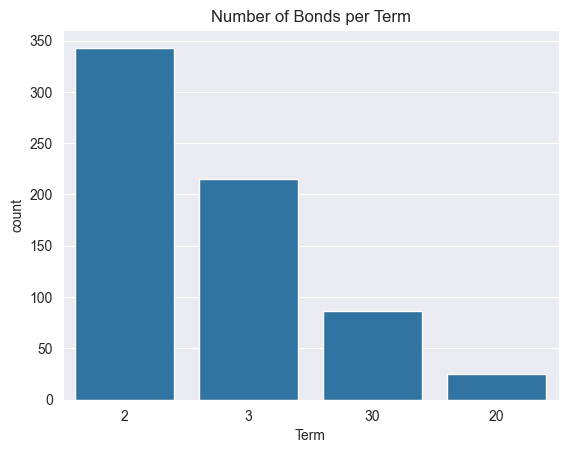

In [45]:
# # Read in the Data
df_data = pd.read_parquet("data/processed_bonds_macro_lag1.parquet")
# display the number of individual bonds for each term
number_of_bonds = df_data[['Term', 'bond']].drop_duplicates().groupby('Term').count().reset_index()
number_of_bonds.columns = ['Term', 'count']
number_of_bonds.sort_values('count', ascending=False, inplace=True)
print(f"Total number of bonds: {len(df_data['bond'].unique())}\n")
sns.barplot(data=number_of_bonds, x='Term', y='count').set_title("Number of Bonds per Term")
# get the max and min dates of the data
print(f"Data is between {df_data['Month'].min()} and {df_data['Month'].max()}")
df_data.head()


## Data Description
The processed data contains information for each bond, including the term and the name of the bond.
The daily price data for each bond was aggregated as the log return of the price from month \( t \) to \( t+1 \).

Other aggregations include:
- Maximum price
- Minimum price
- Log return between the minimum and maximum prices

The log return of the difference was calculated so that the values are on a similar scale to the log return calculations.
The log return of the price data is also discretized into **“increase”** and **“decrease”** values,
where “increase” corresponds to a log return \( x > 0 \).

This data is merged with the macroeconomic data, where the values are aggregated in a manner similar to the bonds.
Daily macroeconomic variables are aggregated into:
- Monthly return values
- Discretized return variables
- Maximum and minimum values from month \( t \) to \( t+1 \)
- Log return difference between the maximum and minimum values

Monthly and quarterly variables do **not** include the maximum and minimum values or their associated calculations.

```text

        Month
        └─ Term
           └─ Bond
              └─ Values
                 ├─ log return values between x_{t-1} and x_t
                 ├─ Discretized log returns: x > 0 → increase, else decrease
                 └─ Max, min, and (max − min) on log returns

```

### Dependent Variables:
* Bond log returns at time t+1
* Discretized Bond log returns at time t+1

### Indpendent Variables:
* 1-month lag Macro economic indicator variables. Variable frequencies are monthly and quarterly


In [50]:
# split the data into train and test
df_train = df_data.query("Month < '2022-01-01'")
df_test = df_data.query("Month >= '2022-01-01'")
# get the shape of the data
print(f"Shape of training data:\t{df_train.shape}")
print(f"Shape of test data:\t{df_test.shape}")
# get the null values of each column
print(f"Null values in training data:")
df_train.isnull().sum() / df_train.shape[0]

Shape of training data:	(19060, 101)
Shape of test data:	(7099, 101)
Null values in training data:


level_0                                   0.000000
index                                     0.000000
Month                                     0.000000
bond_log_return                           0.000000
bond_price_max                            0.000000
                                            ...   
Bitcoin_spot_price_max_min_return_diff    0.452099
Money_supply                              0.000000
Money_supply_log_return_sum               0.000000
Money_supply_log_return_discretized       0.000000
Term                                      0.000000
Length: 101, dtype: float64

## Bitcoin
The **Bitcoin spot price** variable has half of its data missing in the training set.
The significant amount of missing data is due to the start date of data collection,
which began in **December 2014**. In contrast, the training data extends as far back as **2000**.

Although the data is incomplete, the objective of the analysis is to fit a **Bayesian linear** or **non-linear** model
to the historical data at time \( t \) in order to estimate the expected return at time \( t+1 \) for a given bond.

The models will dynamically incorporate predictor variables at each time step,
based on the information available at time \( t \).

**Note:** Some variables are recorded **quarterly**, while others are recorded **monthly**.

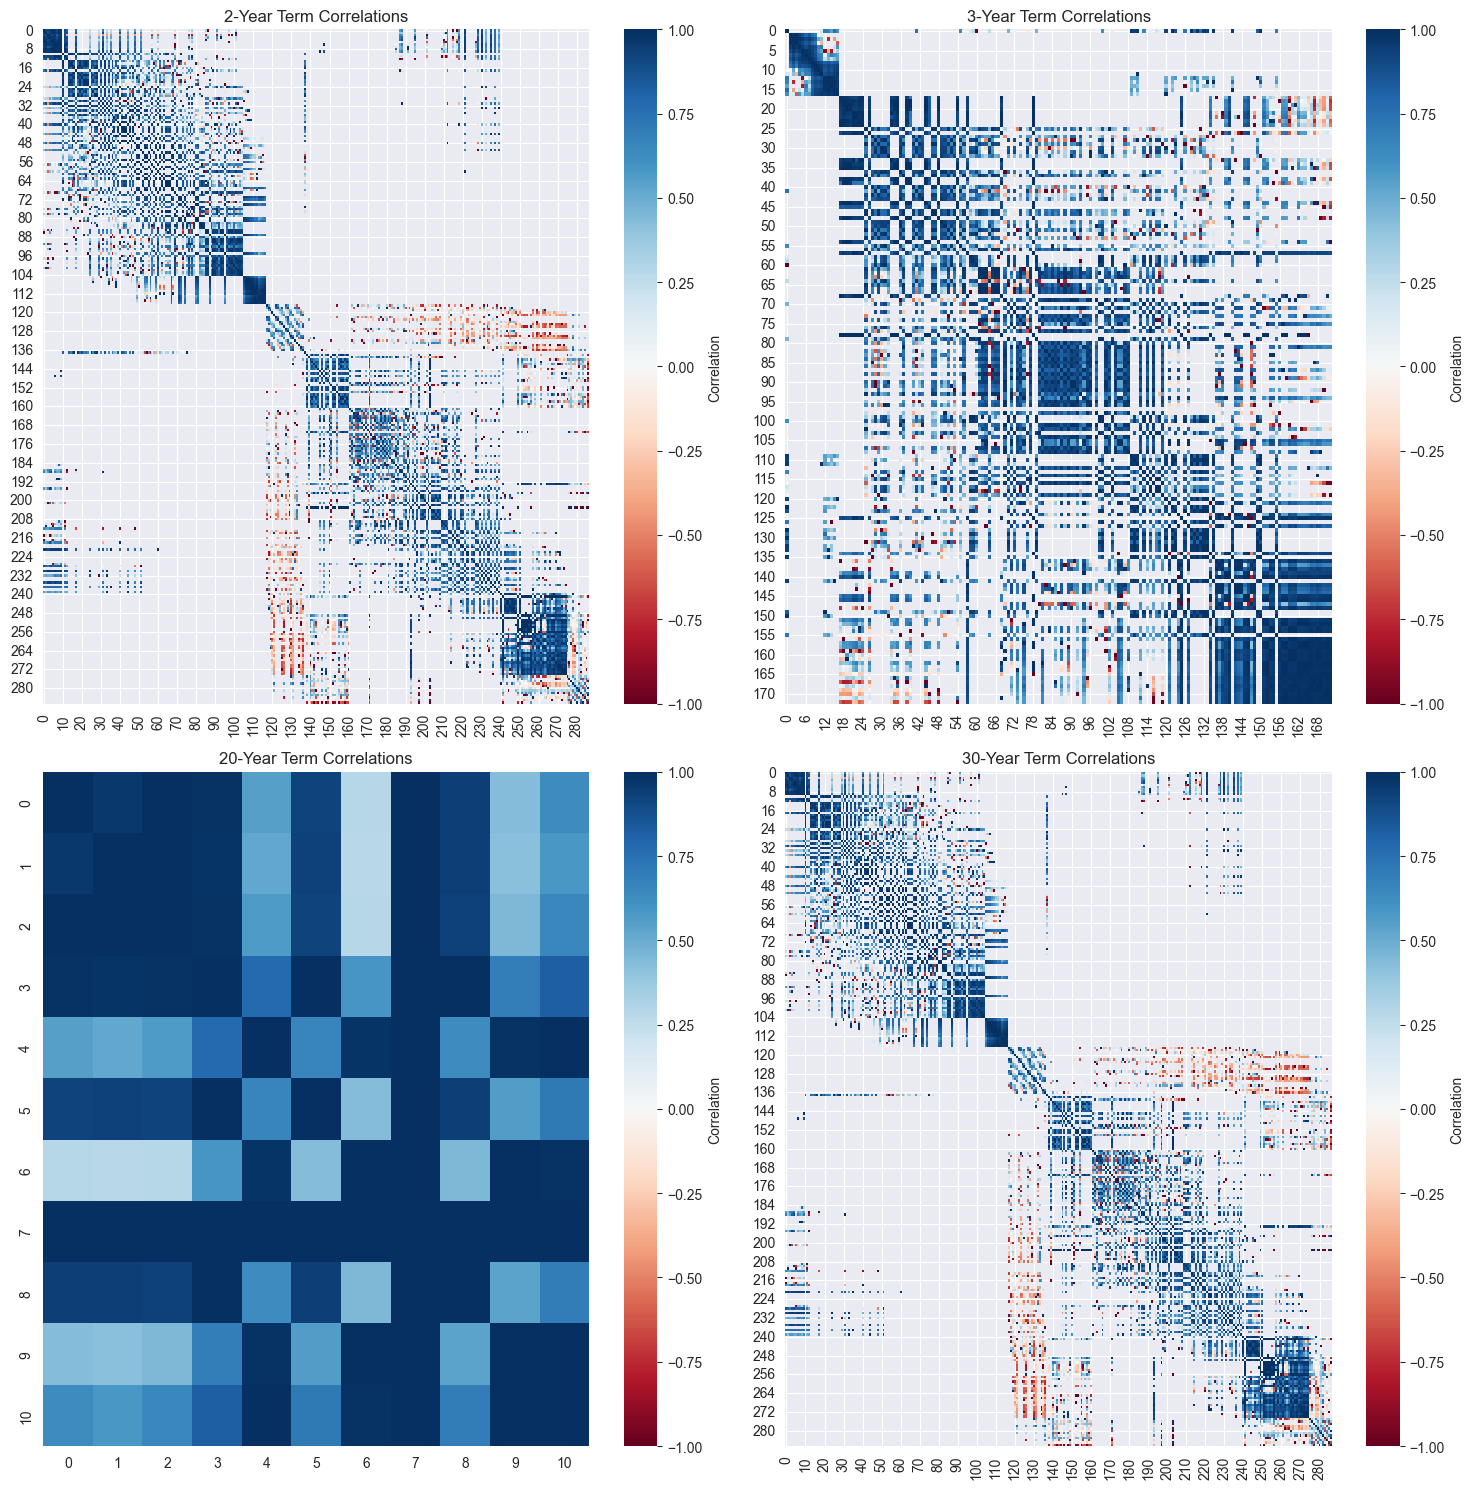

In [21]:
# Answer the question, do bonds with the same term move in tandem and do they have similar distributions
# # plot the correlation heat map of the log returns
# df_2year = df_train[df_train['Term'] == '2'][['Month', 'bond', 'bond_log_return']].pivot(index='Month', columns='bond', values='bond_log_return')
# df_3year = df_train[df_train['Term'] == '3'][['Month', 'bond', 'bond_log_return']].pivot(index='Month', columns='bond', values='bond_log_return')
# df_20year = df_train[df_train['Term'] == '20'][['Month', 'bond', 'bond_log_return']].pivot(index='Month', columns='bond', values='bond_log_return')
# df_30year = df_train[df_train['Term'] == '2'][['Month', 'bond', 'bond_log_return']].pivot(index='Month', columns='bond', values='bond_log_return')

cols_2yr = [x for x in range(len(df_2year.columns))]
cols_3yr = [x for x in range(len(df_3year.columns))]
cols_20yr = [x for x in range(len(df_20year.columns))]
cols_30yr = [x for x in range(len(df_30year.columns))]

df_2year.columns = cols_2yr
df_3year.columns = cols_3yr
df_20year.columns = cols_20yr
df_30year.columns = cols_30yr

# convert the columns to
# correlation
corr2 = df_2year.corr()
corr3 = df_3year.corr()
corr20 = df_20year.corr()
corr30 = df_30year.corr()

# create 4 subplots to plot the correlation heatmap
# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Flatten axes array for easier iteration
axes = axes.flatten()

# List of correlation matrices and their titles
corr_matrices = [corr2, corr3, corr20, corr30]
titles = ['2-Year Term Correlations', '3-Year Term Correlations',
          '20-Year Term Correlations', '30-Year Term Correlations']

# Create heatmaps
for idx, (corr_matrix, title) in enumerate(zip(corr_matrices, titles)):
    sns.heatmap(
        corr_matrix,
        ax=axes[idx],
        cmap='RdBu',      # Red-Blue diverging colormap
        vmin=-1,          # Minimum correlation value
        vmax=1,           # Maximum correlation value
        center=0,         # Center the colormap at 0
        annot=False,      # Don't show annotations
        cbar_kws={'label': 'Correlation'}  # Add label to colorbar
    )
    axes[idx].set_title(title)

    # Remove x and y labels
    axes[idx].set(xlabel=None, ylabel=None)


# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()



## Why are some bonds negatively correlated by term?

A hypothesis is that, as a bond **approaches maturity**, there is an **inverse proportional relationship**
between the **time to maturity** and the **price of the bond**.

What may be happening is that the **correlation** is being calculated between two bonds:
- One nearing maturity
- Another at a point where it is depreciating

We can add another feature to the model, called **time to maturity**, to test this theory.


/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_38160/4145441462.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_term, x='bond_log_return', hue='bond', ax=axes[i], legend=False)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_38160/4145441462.py:7: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_term, x='bond_log_return', hue='bond', ax=axes[i], legend=False)


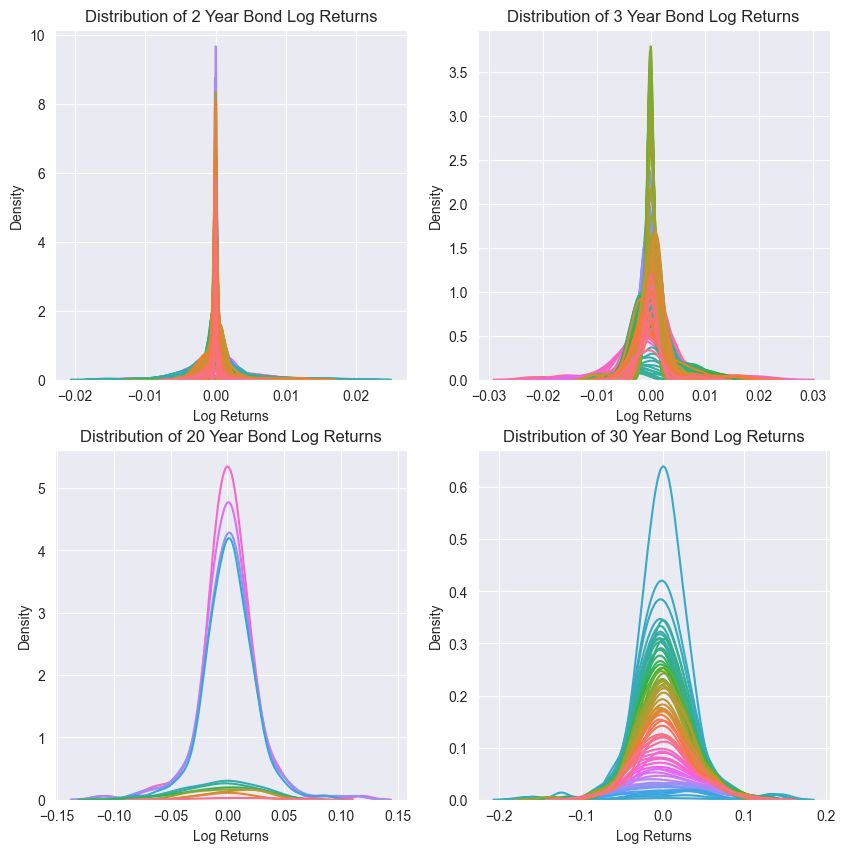

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
i = 0
terms = ['2', '3', '20', '30']
for term in terms:
    df_term = df_train[df_train['Term'] == f"{term}"]
    sns.kdeplot(df_term, x='bond_log_return', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f"Distribution of {term} Year Bond Log Returns")
    axes[i].set_xlabel("Log Returns")
    axes[i].set_ylabel("Density")
    i += 1

/Users/mma0277/Documents/Development/investment_analysis/iv_analysis/lib/python3.10/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/Users/mma0277/Documents/Development/investment_analysis/iv_analysis/lib/python3.10/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/Users/mma0277/Documents/Development/investment_analysis/iv_analysis/lib/python3.10/site-packages/scipy/stats/_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


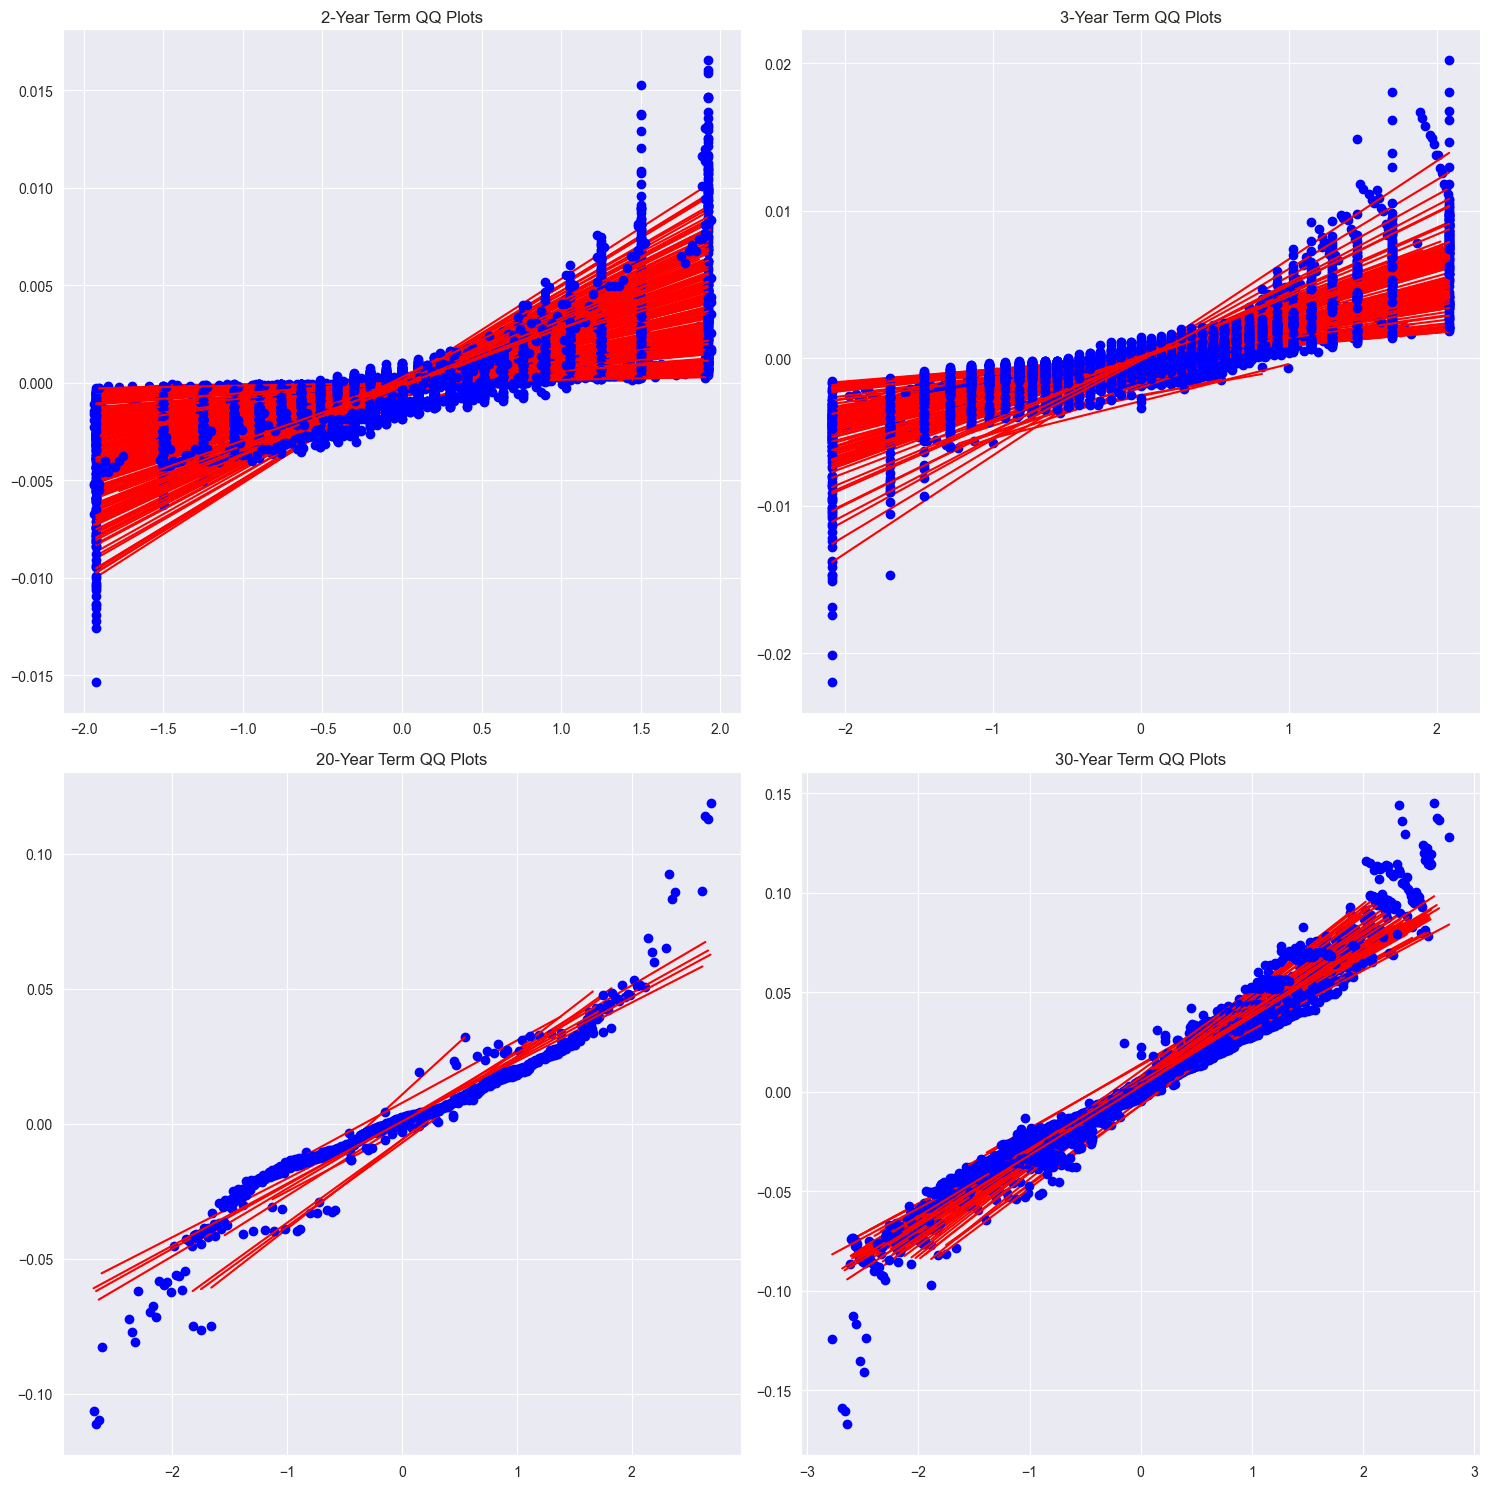

In [27]:
# Set up the figure layout
# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# Flatten axes array for easier iteration
axes = axes.flatten()

# Terms to analyze
terms = [2, 3, 20, 30]
titles = ['2-Year Term QQ Plots', '3-Year Term QQ Plots',
          '20-Year Term QQ Plots', '30-Year Term QQ Plots']

# Create QQ plots for each term
for idx, (term, title) in enumerate(zip(terms, titles)):
    # Get data for current term
    term_data = df_train[df_train['term'] == term]

    # Get unique bonds for this term
    bonds = term_data['bond'].unique()

    # Create QQ plot for each bond in the term
    for bond in bonds:
        bond_returns = term_data[term_data['bond'] == bond]['bond_log_return'].dropna()
        stats.probplot(bond_returns, dist="norm", plot=axes[idx])

    # Set title and remove legend
    axes[idx].set_title(title)
    axes[idx].get_legend().remove() if axes[idx].get_legend() is not None else None

    # Remove x and y labels
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


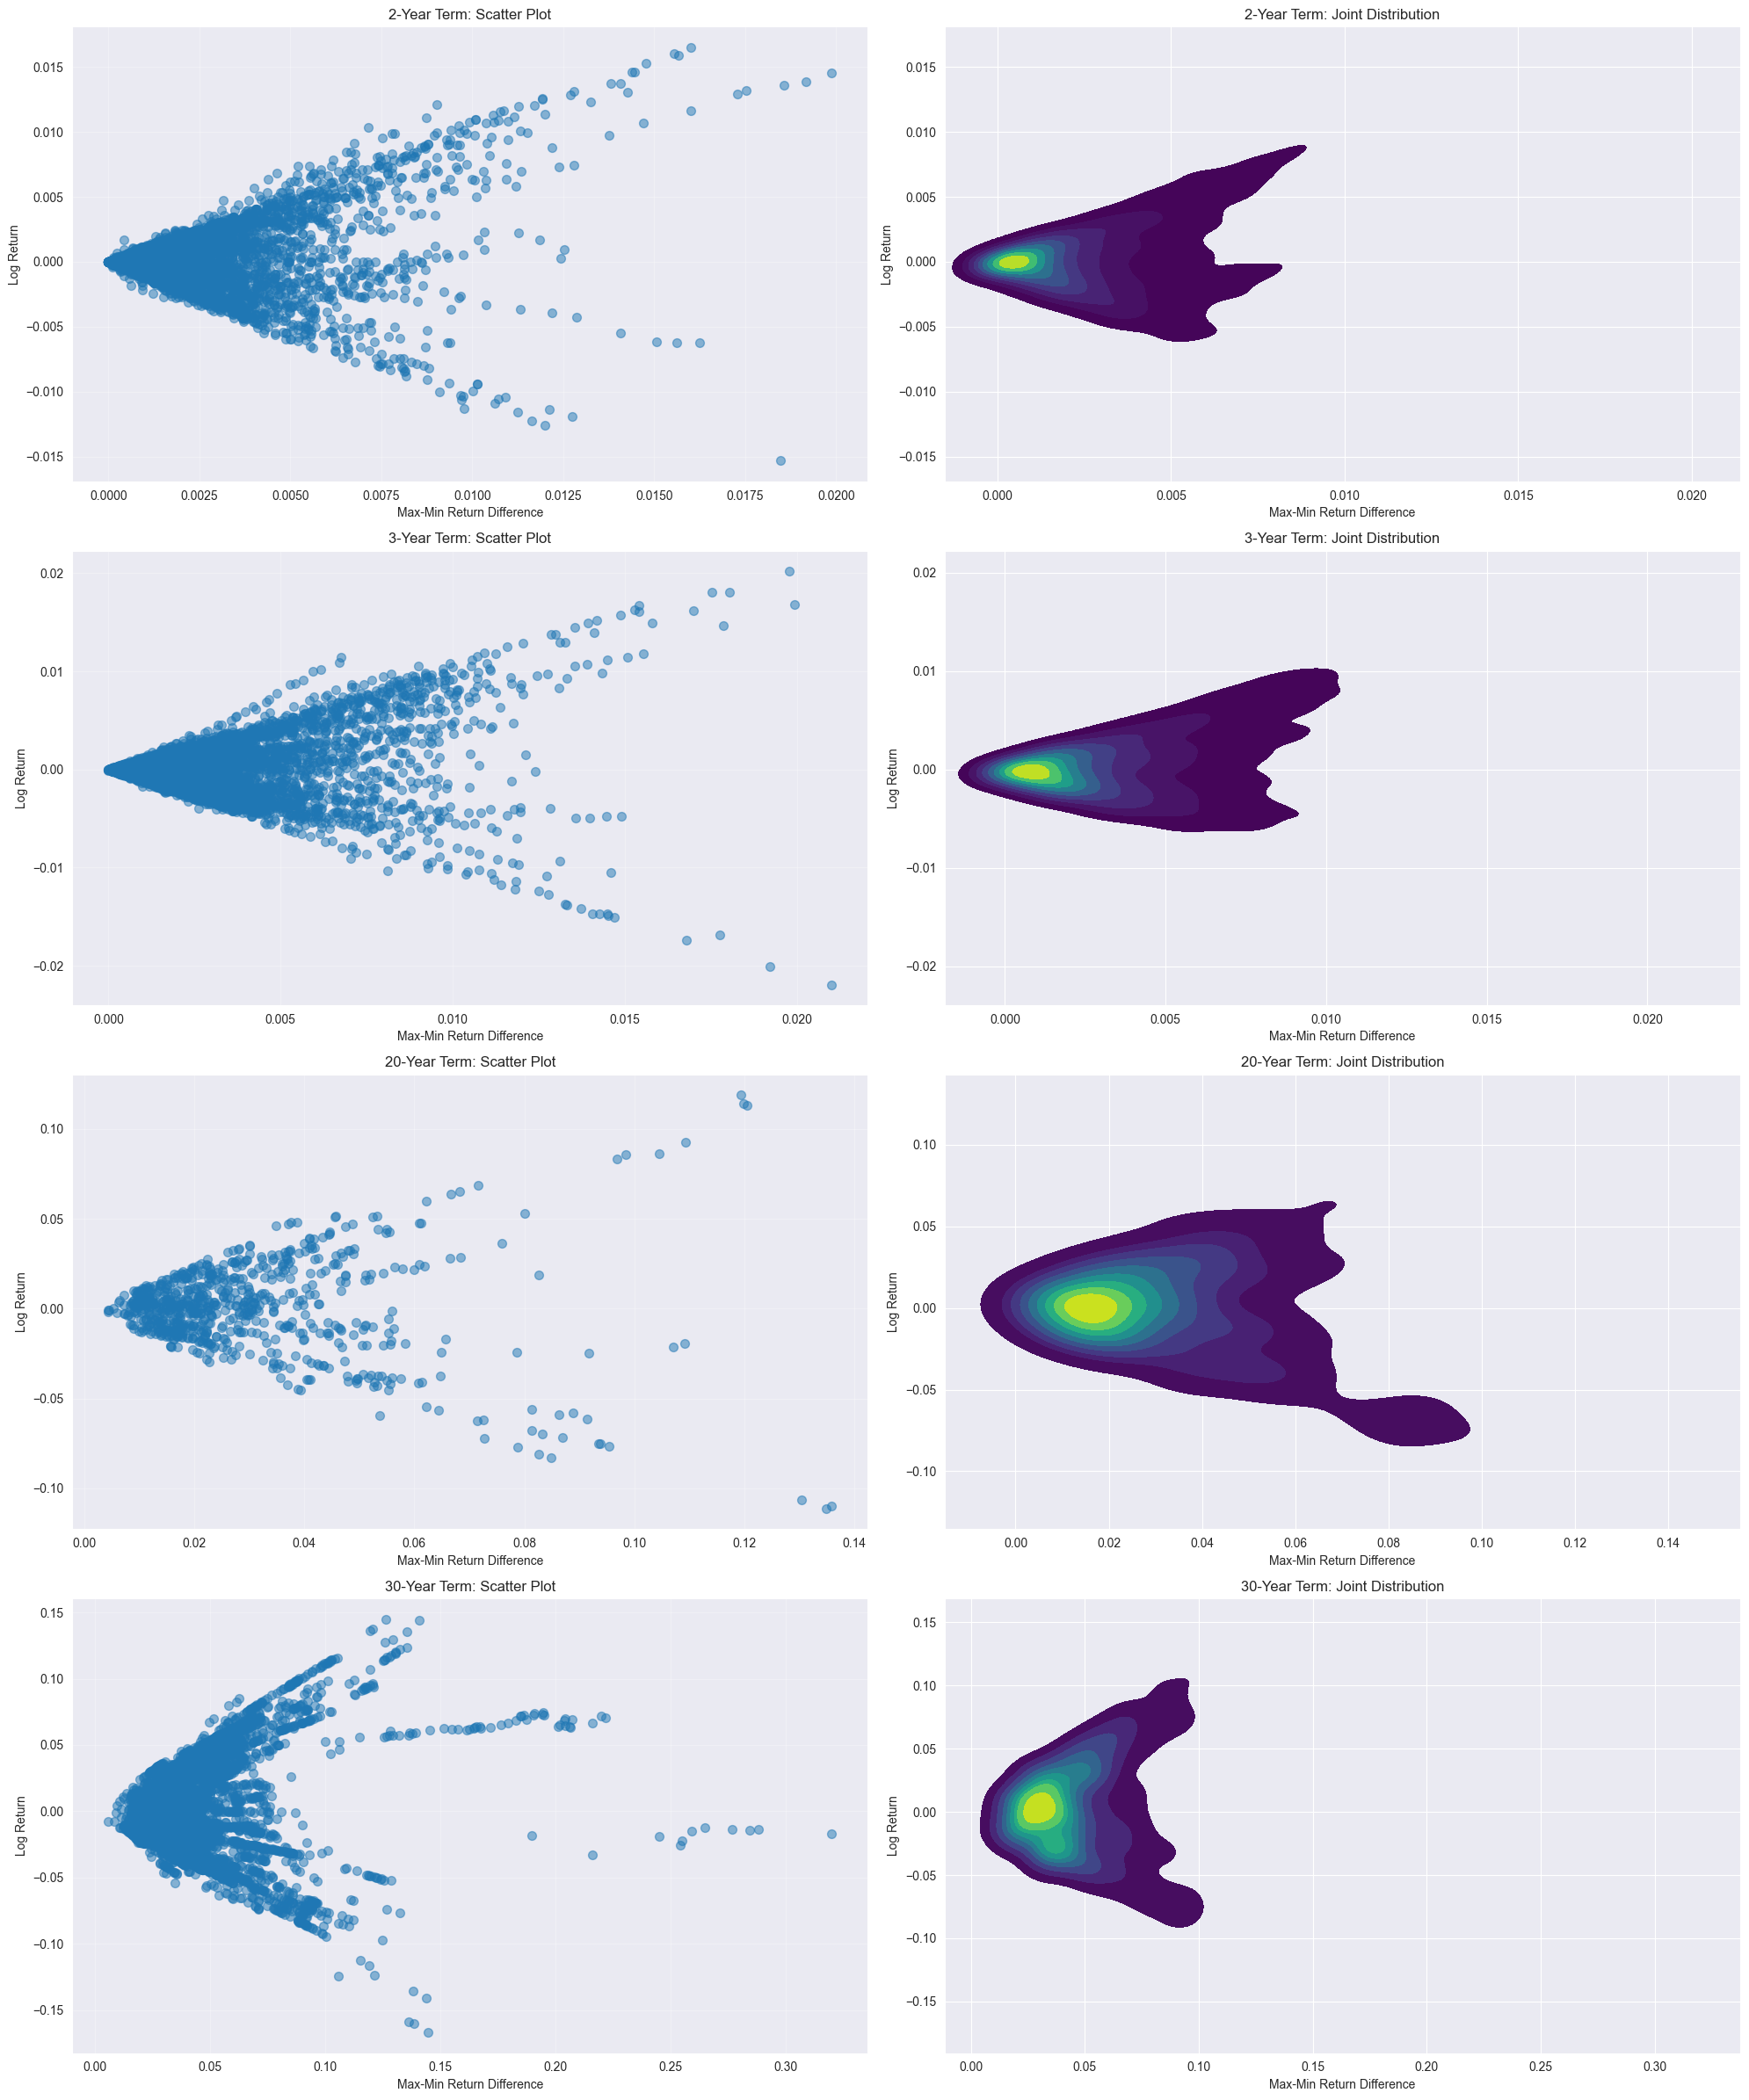


Summary Statistics for 2-Year Term:
--------------------------------------------------
       bond_max_min_return_diff  bond_log_return
count                       0.0              0.0
mean                        NaN              NaN
std                         NaN              NaN
min                         NaN              NaN
25%                         NaN              NaN
50%                         NaN              NaN
75%                         NaN              NaN
max                         NaN              NaN

Correlation coefficient:                           bond_max_min_return_diff  bond_log_return
bond_max_min_return_diff                       NaN              NaN
bond_log_return                                NaN              NaN

Summary Statistics for 3-Year Term:
--------------------------------------------------
       bond_max_min_return_diff  bond_log_return
count                       0.0              0.0
mean                        NaN              NaN
std   

In [51]:
# Set figure size
fig, axes = plt.subplots(4, 2, figsize=(20, 24))

# Define terms
terms = [2, 3, 20, 30]

# Create plots for each term
for idx, term in enumerate(terms):
    # Filter data for current term
    term_data = df_train[df_train['term'] == term]

    # Scatter plot
    axes[idx, 0].scatter(term_data['bond_max_min_return_diff'],
                        term_data['bond_log_return'],
                        alpha=0.5,
                        s=50)
    axes[idx, 0].set_xlabel('Max-Min Return Difference')
    axes[idx, 0].set_ylabel('Log Return')
    axes[idx, 0].set_title(f'{term}-Year Term: Scatter Plot')
    axes[idx, 0].grid(True, alpha=0.3)

    # KDE joint distribution plot
    sns.kdeplot(data=term_data,
                x='bond_max_min_return_diff',
                y='bond_log_return',
                fill=True,
                cmap='viridis',
                ax=axes[idx, 1])
    axes[idx, 1].set_xlabel('Max-Min Return Difference')
    axes[idx, 1].set_ylabel('Log Return')
    axes[idx, 1].set_title(f'{term}-Year Term: Joint Distribution')

# Adjust layout
plt.tight_layout()
plt.show()

# Print summary statistics for each term
for term in terms:
    term_data = df_train[df_train['Term'] == term]
    print(f"\nSummary Statistics for {term}-Year Term:")
    print("-" * 50)
    stats_df = term_data[['bond_max_min_return_diff', 'bond_log_return']].dropna().describe()
    print(stats_df)

    # Calculate correlation
    corr = term_data[['bond_max_min_return_diff', 'bond_log_return']].dropna().corr()
    print(f"\nCorrelation coefficient: {corr}")
    print("=" * 50)


## Bond Log Returns by Term

As displayed in the KDE plot of the monthly bond log returns, all the bonds have a very similar shape,
with most of the values centered around 0.

The distribution resembles a normal distribution but with fat tails, making it leptokurtic.
As the term increases, the variation begins to widen.

This is because longer-term bonds generally have higher yields than shorter-term bonds,
given the extended time until the investor receives their maturity payment.
Higher-yielding bonds also tend to have greater risk associated with them.

For the 2-year and 3-year bonds, there is a higher variance in the shapes of their individual distributions.
This may be due to seasonality effects and the short time frame until maturity.

The seasonality could result from these bonds being auctioned in varying macroeconomic climates.


## Analyzing Discrete Relationships

Below is the analysis of all the discretized values in the dataset.

The dependent variable is the discretized monthly log return.
The independent variables are all the FRED macroeconomic variables, also discretized.

Steps:
1. Chi-Square Test on the dependent variable against all independent variables
2. Calculate the conditional probabilities for the values of the dependent and independent variables
3. Perform logistic regression on the variables to identify significant predictors

In [29]:
# collect the independent and dependent variables
dependent_var = 'return_label'
independent_vars = [x for x in df_train.columns if "_discretized" in x]
print(f"Dependent variable: {dependent_var}\n")
print(f"Independent variables: {independent_vars}")

Dependent variable: return_label

Independent variables: ['5_Year_Inflation_Expectation_log_return_discretized', '10_Year_Inflation_Expectation_log_return_discretized', '10_Year_3_Year_Spread_log_return_discretized', 'Fed_Funds_Rate_log_return_discretized', '10_Year_Term_Premium_log_return_discretized', 'Real_10-Year_Yield_log_return_discretized', 'Effective_Fed_Funds_Rate_Daily_log_return_discretized', 'CPI_Core_log_return_discretized', 'Economic_Policy_Uncertainty_US_log_return_discretized', 'Global_EPU_Index_log_return_discretized', '10_Year_TIPS_Yield_log_return_discretized', '10_Year_Treasury_Yield_log_return_discretized', 'Dollar_Index_log_return_discretized', 'Crude_Oil_Price_WTI_log_return_discretized', '2_Year_Treasury_Yield_log_return_discretized', '5_Year_Treasury_Yield_log_return_discretized', 'WTI_Spot_price_log_return_discretized', 'Industrial_Production_log_return_discretized', 'Manufacturing_Production_log_return_discretized', 'Bitcoin_spot_price_log_return_discretized'

In [38]:
# First, let's create a function to run the chi-square tests and collect results
# def run_chi_square_tests(
#         data: pd.DataFrame,
#         dependent_var: str,
#         independent_vars: list[str],
#         terms: list[int]
# ):
#     """
#     Run the chi-square test for each independent variable against the dependent variable.
#     for each term
#     """
#     results = []
#     # Get unique terms
#     terms = data['Term'].unique()
#     for term in terms:
#         # Filter data for current term
#         term_data = data[data['Term'] == term]
#         # Run test for each independent variable
#         for ind_var in independent_vars:
#             try:
#                 # Create contingency table
#                 contingency = pd.crosstab(term_data[dependent_var], term_data[ind_var])
#                 # Run chi-square test
#                 chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
#                 # Get number of observations
#                 n_obs = len(term_data)
#                 # Store results
#                 results.append({
#                     'Term': term,
#                     'Independent_Variable': ind_var,
#                     'Chi_Square_Statistic': chi2,
#                     'P_Value': p_value,
#                     'N_Observations': n_obs
#                 })
#
#             except Exception as e:
#                 print(f"Error processing {ind_var} for term {term}: {str(e)}")
#
#     # Convert results to DataFrame
#     results_df = pd.DataFrame(results)
#
#     # Sort by Term and P-Value
#     results_df = results_df.sort_values(['Term', 'P_Value'])
#
#     # Format P-Values for readability
#     results_df['P_Value'] = results_df['P_Value'].apply(lambda x: f"{x:.2e}")
#     results_df['Chi_Square_Statistic'] = results_df['Chi_Square_Statistic'].round(2)
#
#     return results_df
#
# # Run the analysis
# results = run_chi_square_tests(df_train, dependent_var, independent_vars, terms=[2, 3, 20, 30])
#
# # Display the results
# print("\nChi-Square Test Results:")
# print(results)
#
# # Let's also create a summary of significant relationships
# alpha = 0.05
# significant_results = results[results['P_Value'].astype(float) < alpha]

print("\nSignificant Relationships (p < 0.05):")

print(f"************************ Dependent variables for the 2 year term ************************")
print(f"{significant_results[significant_results['Term'] == '2']['Independent_Variable'].values}")
print(f"There are {len(significant_results[significant_results['Term'] == '2']['Independent_Variable'].values)} out of {len(independent_vars)} independent variables significant for the 2 year term\n")
print(f"************************ Dependent variables for the 3 year term ************************")
print(f"{significant_results[significant_results['Term'] == '3']['Independent_Variable'].values}")
print(f"There are {len(significant_results[significant_results['Term'] == '3']['Independent_Variable'].values)} out of {len(independent_vars)} independent variables significant for the 3 year term\n")
print(f"************************ Dependent variables for the 20 year term ************************")
print(f"{significant_results[significant_results['Term'] == '20']['Independent_Variable'].values}")
print(f"There are {len(significant_results[significant_results['Term'] == '20']['Independent_Variable'].values)} out of {len(independent_vars)} independent variables significant for the 20 year term\n")
print(f"************************ Dependent variables for the 30 year term ************************")
print(f"{significant_results[significant_results['Term'] == '30']['Independent_Variable'].values}")
print(f"There are {len(significant_results[significant_results['Term'] == '3']['Independent_Variable'].values)} out of {len(independent_vars)} independent variables significant for the 3 year term\n")



Significant Relationships (p < 0.05):
************************ Dependent variables for the 2 year term ************************
['2_Year_Treasury_Yield_log_return_discretized'
 '5_Year_Treasury_Yield_log_return_discretized'
 '10_Year_Treasury_Yield_log_return_discretized'
 '10_Year_Term_Premium_log_return_discretized'
 '10_Year_TIPS_Yield_log_return_discretized'
 '10_Year_3_Year_Spread_log_return_discretized'
 '5_Year_Inflation_Expectation_log_return_discretized'
 '10_Year_Inflation_Expectation_log_return_discretized'
 'Crude_Oil_Price_WTI_log_return_discretized'
 'Effective_Fed_Funds_Rate_Daily_log_return_discretized'
 'Global_EPU_Index_log_return_discretized'
 'Dollar_Index_log_return_discretized'
 'Manufacturing_Production_log_return_discretized'
 'WTI_Spot_price_log_return_discretized'
 'Industrial_Production_log_return_discretized'
 'Bitcoin_spot_price_log_return_discretized'
 'Fed_Funds_Rate_log_return_discretized' 'CPI_Core_log_return_discretized']
That is 18 out of 21 independ